In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\archive (1)\pharmacy dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           333 non-null    object 
 1   Product        333 non-null    object 
 2   Sales Person   333 non-null    object 
 3   Boxes Shipped  333 non-null    int64  
 4   Amount ($)     333 non-null    float64
 5   Country        333 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 15.7+ KB


In [14]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\archive (1)\pharmacy dataset.csv")

In [8]:
# Check basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (333, 6)

Columns: ['Date', 'Product', 'Sales Person', 'Boxes Shipped', 'Amount ($)', 'Country']

First 5 rows:


,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country
0,2022-02-06,Pain Relief Tablets,Divya Mehra,7,67.43,Australia
1,2022-02-05,Antiseptic Cream,Nikhil Batra,18,421.46,Canada
2,2022-02-19,Cough Syrup,Ritika Shah,2,48.25,UK
3,2022-03-28,Pain Relief Tablets,Nikhil Batra,5,59.89,UK
4,2022-01-17,Digestive Enzyme,Ritika Shah,8,147.73,USA


In [15]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values in each column:
Date             0
Product          0
Sales Person     0
Boxes Shipped    0
Amount ($)       0
Country          0
dtype: int64

Data types:
Date              object
Product           object
Sales Person      object
Boxes Shipped      int64
Amount ($)       float64
Country           object
dtype: object

Total duplicate rows: 0


In [16]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Year for analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("Date column fixed!")
print(df.dtypes)
df.head()

Date column fixed!
Date             datetime64[ns]
Product                  object
Sales Person             object
Boxes Shipped             int64
Amount ($)              float64
Country                  object
Month                     int32
Year                      int32
dtype: object


,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country,Month,Year
0,2022-02-06,Pain Relief Tablets,Divya Mehra,7,67.43,Australia,2,2022
1,2022-02-05,Antiseptic Cream,Nikhil Batra,18,421.46,Canada,2,2022
2,2022-02-19,Cough Syrup,Ritika Shah,2,48.25,UK,2,2022
3,2022-03-28,Pain Relief Tablets,Nikhil Batra,5,59.89,UK,3,2022
4,2022-01-17,Digestive Enzyme,Ritika Shah,8,147.73,USA,1,2022


In [17]:
# Top 5 selling products by boxes shipped
print("Top 5 Products by Boxes Shipped:")
print(df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False).head())

print("\nTop 5 Products by Revenue:")
print(df.groupby('Product')['Amount ($)'].sum().sort_values(ascending=False).head())

print("\nSales by Country:")
print(df.groupby('Country')['Amount ($)'].sum().sort_values(ascending=False))

Top 5 Products by Boxes Shipped:
Product
Digestive Enzyme    612
Antiseptic Cream    573
Allergy Pills       518
Nasal Spray         489
Cough Syrup         484
Name: Boxes Shipped, dtype: int64

Top 5 Products by Revenue:
Product
Digestive Enzyme    11056.61
Antiseptic Cream     9736.28
Nasal Spray          8407.36
Eye Drops            8036.36
Cough Syrup          7917.01
Name: Amount ($), dtype: float64

Sales by Country:
Country
USA          14109.48
UK           12032.30
Canada       11967.08
India        11122.06
Australia     9698.37
Name: Amount ($), dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

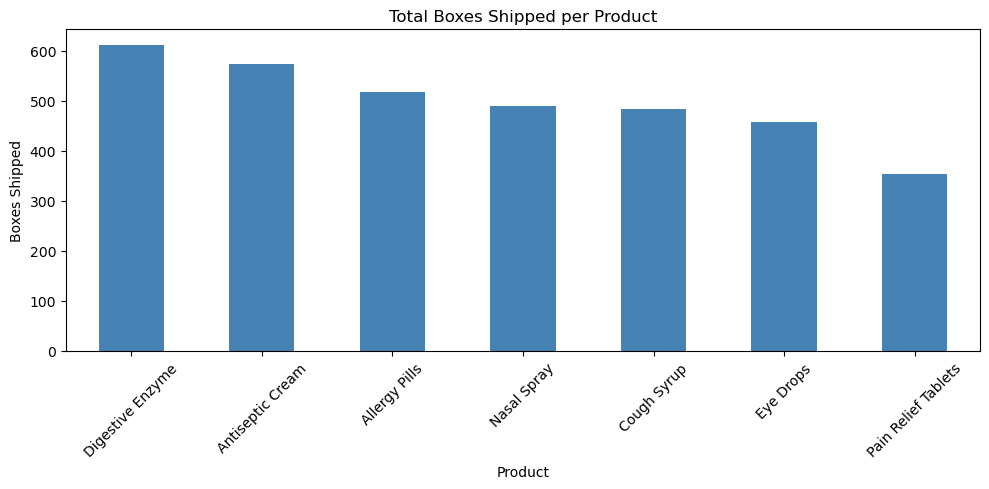

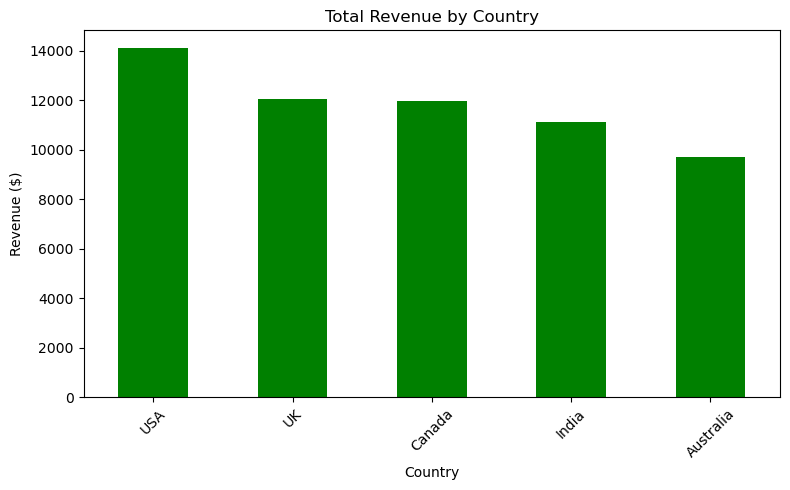

In [23]:
# Bar chart - Top products by boxes shipped
plt.figure(figsize=(10,5))
df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Total Boxes Shipped per Product')
plt.xlabel('Product')
plt.ylabel('Boxes Shipped')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar chart - Revenue by Country
plt.figure(figsize=(8,5))
df.groupby('Country')['Amount ($)'].sum().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

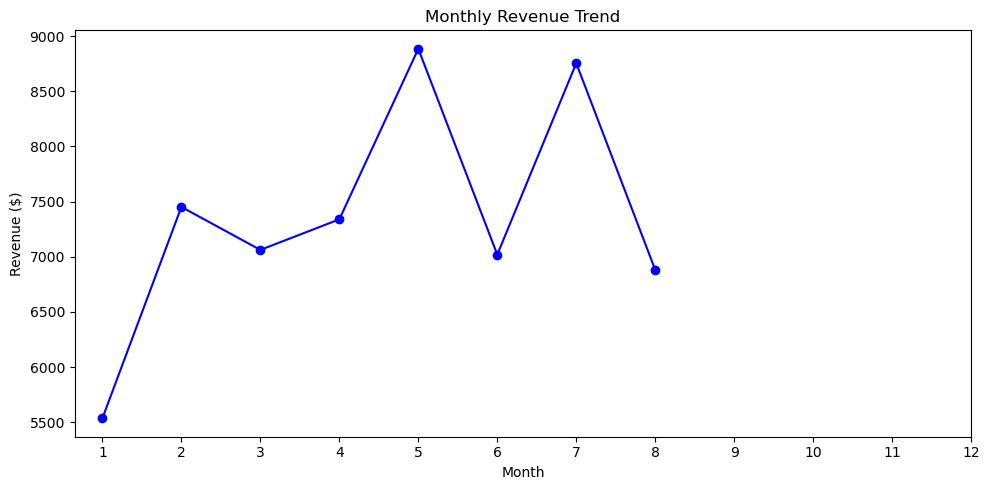

In [24]:
# Monthly revenue trend
plt.figure(figsize=(10,5))
df.groupby('Month')['Amount ($)'].sum().plot(kind='line', marker='o', color='blue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

In [25]:
# Prepare data for prediction
monthly_sales = df.groupby('Month')['Amount ($)'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total Sales']

print(monthly_sales)

   Month  Total Sales
0      1      5536.39
1      2      7451.50
2      3      7062.15
3      4      7339.15
4      5      8885.00
5      6      7019.56
6      7      8754.44
7      8      6881.10


In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare X and Y
X = monthly_sales[['Month']]
Y = monthly_sales['Total Sales']

# Build model
model = LinearRegression()
model.fit(X, Y)

# Predict next 2 months (9 and 10)
next_months = pd.DataFrame({'Month': [9, 10]})
predictions = model.predict(next_months)

print(f"Predicted Sales for Month 9: ${predictions[0]:.2f}")
print(f"Predicted Sales for Month 10: ${predictions[1]:.2f}")

Predicted Sales for Month 9: $8295.40
Predicted Sales for Month 10: $8501.89


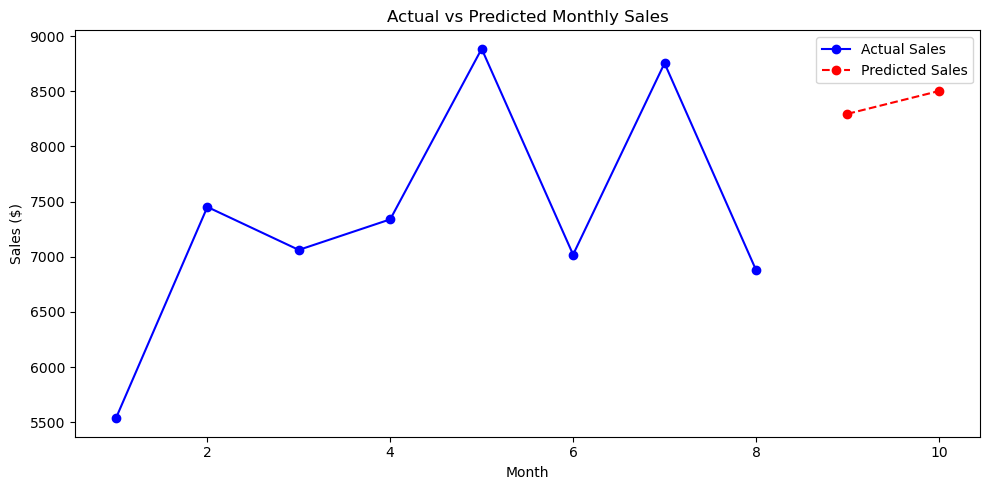

In [27]:
# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Total Sales'], 
         marker='o', color='blue', label='Actual Sales')
plt.plot([9,10], predictions, 
         marker='o', color='red', linestyle='--', label='Predicted Sales')
plt.title('Actual vs Predicted Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

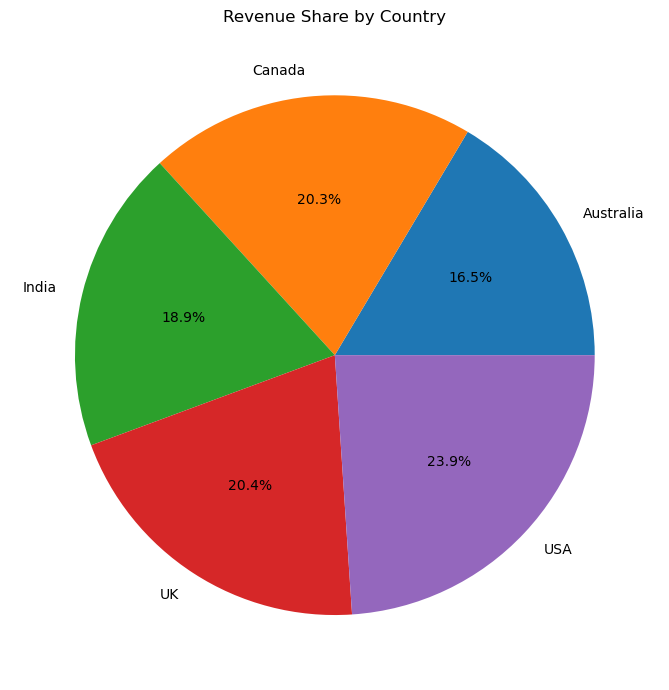

In [28]:
# Pie chart - Revenue by Country
plt.figure(figsize=(7,7))
df.groupby('Country')['Amount ($)'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Country')
plt.ylabel('')
plt.tight_layout()
plt.show()